In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 12, 8

In [3]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client = Client('IRIS', debug=True)

Installed new opener with handlers: [<obspy.clients.fdsn.client.CustomRedirectHandler object at 0x73523c759420>]
Base URL: http://service.iris.edu
Request Headers: {'User-Agent': 'ObsPy/1.4.1 (Linux-6.5.0-35-generic-x86_64-with-glibc2.35, Python 3.10.12)'}
Uncompressing gzipped response for http://service.iris.edu/fdsnws/event/1/contributors
Downloaded http://service.iris.edu/fdsnws/event/1/contributors with HTTP code: 200
Downloaded http://service.iris.edu/fdsnws/event/1/catalogs with HTTP code: 200
Downloaded http://service.iris.edu/fdsnws/station/1/application.wadl with HTTP code: 200
Uncompressing gzipped response for http://service.iris.edu/fdsnws/event/1/application.wadl
Downloaded http://service.iris.edu/fdsnws/event/1/application.wadl with HTTP code: 200
Uncompressing gzipped response for http://service.iris.edu/fdsnws/dataselect/1/application.wadl
Downloaded http://service.iris.edu/fdsnws/dataselect/1/application.wadl with HTTP code: 200
Discovered station service
Discovered e

In [4]:
time = UTCDateTime("2019-07-06T03:19:53.04")
print(time)

2019-07-06T03:19:53.040000Z


In [5]:
starttime = time - 60 
print(starttime)

2019-07-06T03:18:53.040000Z


In [6]:
endtime = time + 60*15
print(endtime)

2019-07-06T03:34:53.040000Z


Downloaded http://service.iris.edu/fdsnws/dataselect/1/query?starttime=2019-07-06T03%3A18%3A53.040000&endtime=2019-07-06T03%3A34%3A53.040000&network=IU&station=TUC&location=00&channel=HH%2A with HTTP code: 200
3 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HH2 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HHZ | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


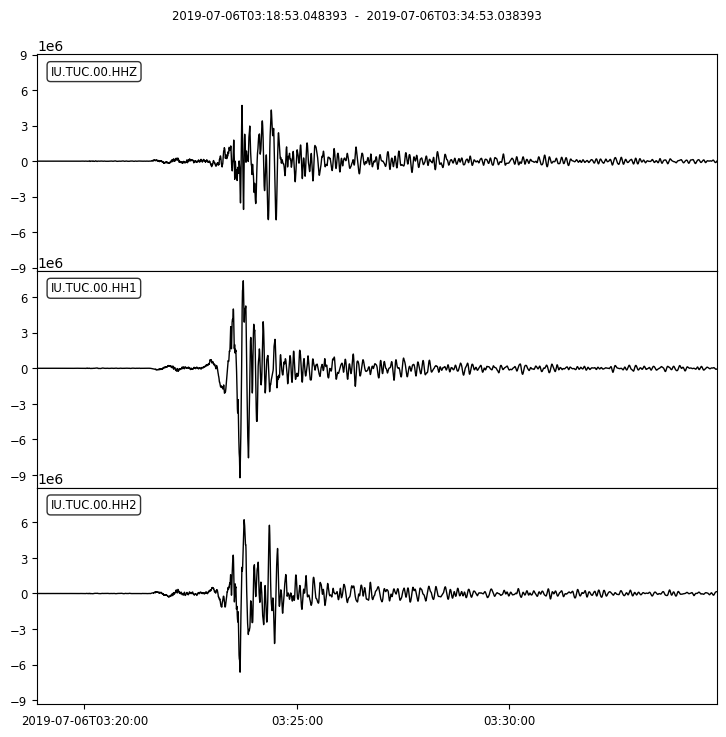

In [26]:
net = "IU"
sta = "TUC"
loc = "00"
chan = "HH*"

st = client.get_waveforms(net, sta, loc, chan, starttime, endtime)
print(st)
st.plot();

In [27]:
st_rem = st.copy()
print(st)
print(st_rem)

3 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HH2 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HHZ | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
3 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HH2 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
IU.TUC.00.HHZ | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


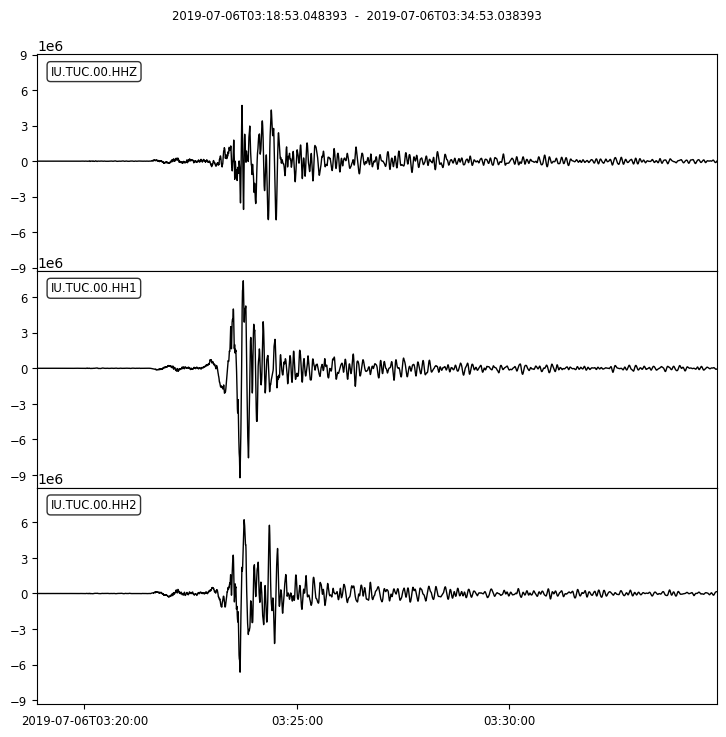

In [17]:
st_rem.plot();

In [7]:
minlat = 20.835
maxlat = 51.913

minlon = -135.721
maxlon = -99.810

starttime = UTCDateTime("2019-07-01T00:00:00")
endtime = UTCDateTime("2019-07-10T00:00:00")

minmag = 4
maxmag = 9.0


events = client.get_events(minlatitude=minlat, maxlatitude=maxlat,
                          minlongitude=minlon, maxlongitude=maxlon,
                          minmagnitude=minmag, maxmagnitude=maxmag,
                          starttime=starttime, endtime=endtime)



title = 'M<%d -- %s to %s -- %d total events' % (
    maxmag,
    starttime,
    endtime,
    len(events))

print("found %s event(s):" % len(events))
print(events)

Uncompressing gzipped response for http://service.iris.edu/fdsnws/event/1/query?starttime=2019-07-01T00%3A00%3A00.000000&endtime=2019-07-10T00%3A00%3A00.000000&minlatitude=20.835&maxlatitude=51.913&minlongitude=-135.721&maxlongitude=-99.81&minmagnitude=4.0&maxmagnitude=9.0
Downloaded http://service.iris.edu/fdsnws/event/1/query?starttime=2019-07-01T00%3A00%3A00.000000&endtime=2019-07-10T00%3A00%3A00.000000&minlatitude=20.835&maxlatitude=51.913&minlongitude=-135.721&maxlongitude=-99.81&minmagnitude=4.0&maxmagnitude=9.0 with HTTP code: 200
found 105 event(s):
105 Event(s) in Catalog:
2019-07-07T23:36:56.970000Z | +35.828, -117.671 | 4.1  ML
2019-07-07T11:22:16.270000Z | +35.806, -117.592 | 4.2  Mwr
...
2019-07-03T22:32:31.614000Z | +44.484, -128.935 | 4.1  mb
2019-07-03T15:15:20.055000Z | +44.397, -129.080 | 4.1  mb
To see all events call 'print(CatalogObject.__str__(print_all=True))'


In [8]:
import pandas as pd

df = pd.DataFrame(columns=['time', 'latitude', 'longitude', 'depth', 'mag', 'magnitude_type', 'creation_info', 'info'])
    
    # Populate the DataFrame with event data
for i in range(len(events)):
        df.loc[i, 'time'] = events[i].origins[0].time
        df.loc[i, 'latitude'] = events[i].origins[0].latitude
        df.loc[i, 'longitude'] = events[i].origins[0].longitude
        df.loc[i, 'depth'] = events[i].origins[0].depth
        df.loc[i, 'mag'] = events[i].magnitudes[0].mag
        df.loc[i, 'magnitude_type'] = events[i].magnitudes[0].magnitude_type
        
        # Handle potential missing creation_info or event_descriptions
        creation_info = getattr(events[i].origins[0], 'creation_info', None)
        df.loc[i, 'creation_info'] = creation_info if creation_info else 'N/A'
        
        event_description = events[i].event_descriptions[0].text if events[i].event_descriptions else 'N/A'
        df.loc[i, 'info'] = event_description

In [9]:
df

,time,latitude,longitude,depth,mag,magnitude_type,creation_info,info
0,2019-07-07T23:36:56.970000Z,35.828499,-117.671333,4000.0,4.1,ML,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
1,2019-07-07T11:22:16.270000Z,35.805832,-117.591667,9840.0,4.2,Mwr,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
2,2019-07-07T05:38:15.480000Z,35.768167,-117.577833,10570.0,4.5,Mwr,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
3,2019-07-06T23:50:41.990000Z,35.8235,-117.663,6510.0,4.5,Mw,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
4,2019-07-06T16:36:05.820000Z,35.5705,-117.523,10050.0,4.1,Mwr,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
...,...,...,...,...,...,...,...,...
100,2019-07-04T17:35:01.660000Z,35.644,-117.567167,4640.0,4.49,Mlr,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
101,2019-07-04T17:33:49.040000Z,35.705167,-117.506,10710.0,6.4,mw,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA
102,2019-07-04T04:30:44.297000Z,51.2215,-130.515,10000.0,6.2,Mww,"[agency_id, agency_uri, author, author_uri, cr...",QUEEN CHARLOTTE ISLANDS REGION
103,2019-07-03T22:32:31.614000Z,44.4836,-128.935,10000.0,4.1,mb,"[agency_id, agency_uri, author, author_uri, cr...",OFF COAST OF OREGON


In [10]:
earthquake_data = np.zeros((len(df),3,12000))
earthquake_data.shape

(105, 3, 12000)

In [11]:
#EARTHQUAKE DATA

In [12]:
import numpy as np
import obspy
from obspy.clients.fdsn import Client

# Initialize FDSN client
client = Client("IRIS")

# Assuming df and earthquake_data are predefined
# Example initialization of earthquake_data
# earthquake_data = np.zeros((len(df), 3, 2000))  # Adjust dimensions as needed

for i in range(len(df)):
    st = obspy.UTCDateTime(df['time'][i].datetime.strftime("%Y-%m-%d %H:%M:%S"))
    try:
        wavedata = client.get_waveforms(network="IU",
                                        station="TUC",
                                        location="00",
                                        channel="BH*",
                                        starttime=st,
                                        endtime=st+300)
    except Exception as e:
        print(f"Error fetching data for event at {st}: {e}")
        continue

    # Check the length of wavedata to ensure it has at least 3 elements
    if len(wavedata) < 3:
        print(f"Warning: Expected 3 traces, but got {len(wavedata)} for event at {st}. Skipping this event.")
        continue

    for j in range(3):
        trace_data = wavedata[j].data
        max_val = abs(trace_data).max()

        if max_val == 0:
            print(f"Warning: Maximum value of trace {j} for event at {st} is zero. Skipping this trace.")
            continue

        if len(trace_data) < 12000:
            p = list(trace_data / max_val)
            diff = 12000 - len(trace_data)
            p.extend([0] * diff)
            earthquake_data[i, j, :] = np.array(p)
        elif len(trace_data) > 12000:
            earthquake_data[i, j, :] = trace_data[:12000] / max_val
        else:
            earthquake_data[i, j, :] = trace_data / max_val

    if (i + 1) % 50 == 0:
        print(f"{i + 1} earthquake samples collected...")

print("Total number of earthquake samples: ", earthquake_data.shape[0])


50 earthquake samples collected...
100 earthquake samples collected...
Total number of earthquake samples:  105


In [57]:
print(earthquake_data[30,:])

[[ 0.25409549  0.24900953  0.24315883 ... -0.36829933 -0.36421766
  -0.3600715 ]
 [-0.08051801 -0.07518557 -0.06905593 ...  0.06109271  0.06192535
   0.0625454 ]
 [-0.30664259 -0.30411646 -0.30227612 ...  0.31433383  0.32002847
   0.32555818]]


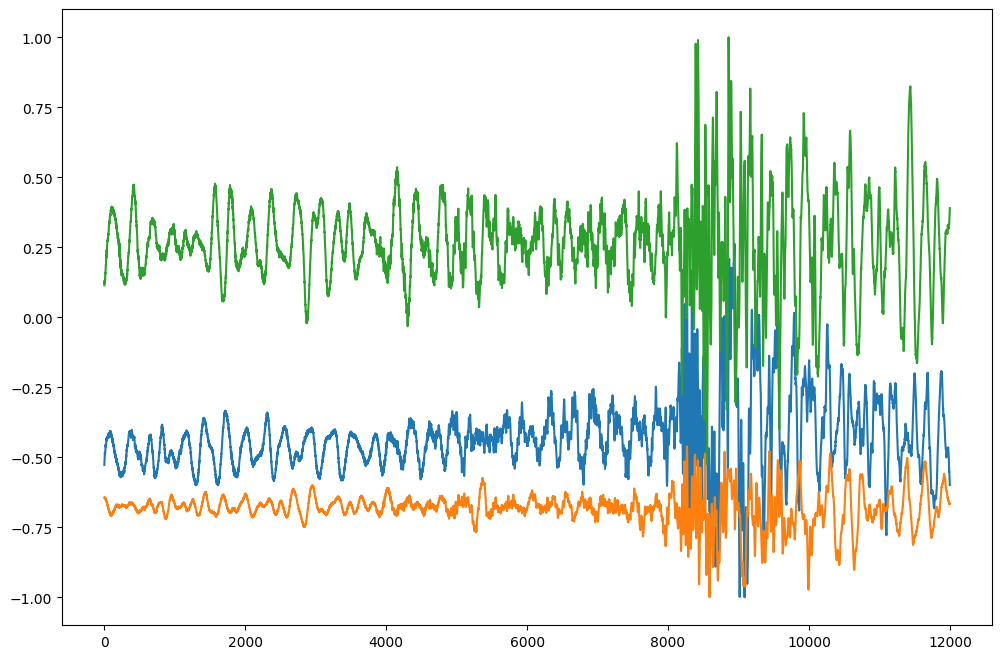

In [71]:
plt.plot(earthquake_data[80, :].T)

In [15]:
#NON_EARTHQUAKE DATA

In [32]:
import numpy as np
import obspy
from obspy.clients.fdsn import Client

# Initialize FDSN client
client = Client("IRIS")

# Assuming df is a DataFrame with earthquake event details and contains a column named 'time' with UTC times of events
# Example initialization of noise_data
noise_data = np.zeros((1000, 3, 12000))  # Adjust dimensions as needed

noise = []
s = 0
while s < 1000:
    for j in range(len(df)):
        # Offset the start time by a random amount to ensure non-overlapping with earthquake events
        st = obspy.UTCDateTime(df['time'][j].datetime.strftime("%Y-%m-%d %H:%M:%S")) + 1000 + s * 40
        
        try:
            wavedata = client.get_waveforms(network="IU",
                                            station="TUC",
                                            location="00",
                                            channel="BH*",
                                            starttime=st,
                                            endtime=st + 300)
        except Exception as e:
            print(f"Error fetching data for time {st}: {e}")
            continue

        if len(wavedata) < 3:
            print(f"Warning: Expected 3 traces, but got {len(wavedata)} for time {st}. Skipping this event.")
            continue

        noise2 = np.zeros((3, 12000))
        for j in range(3):
            trace_data = wavedata[j].data
            max_val = abs(trace_data).max()

            if max_val == 0:
                print(f"Warning: Maximum value of trace {j} for time {st} is zero. Skipping this trace.")
                continue

            if len(trace_data) < 12000:
                p = list(trace_data / max_val)
                diff = 12000 - len(trace_data)
                p.extend([0] * diff)
                noise2[j] = np.array(p)
            elif len(trace_data) > 12000:
                noise2[j] = trace_data[:12000] / max_val
            else:
                noise2[j] = trace_data / max_val

        noise.append(noise2)
        s += 1

        if s % 100 == 0:
            print(f"{s} non-earthquake samples collected...")

        if s >= 1000:
            break

noise_data = np.array(noise)
print("Total number of non-earthquake samples: ", noise_data.shape[0])


100 non-earthquake samples collected...
200 non-earthquake samples collected...
300 non-earthquake samples collected...
400 non-earthquake samples collected...
Error fetching data for time 2019-07-06T08:52:39.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:50:04.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:49:33.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:48:06.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:44:32.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:37:56.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:36:45.000000Z: 'URLError' object has no attribute 'splitlines'
Error fetching data for time 2019-07-06T08:35:50.000000Z: 'URLError' object has no attribute 'spli

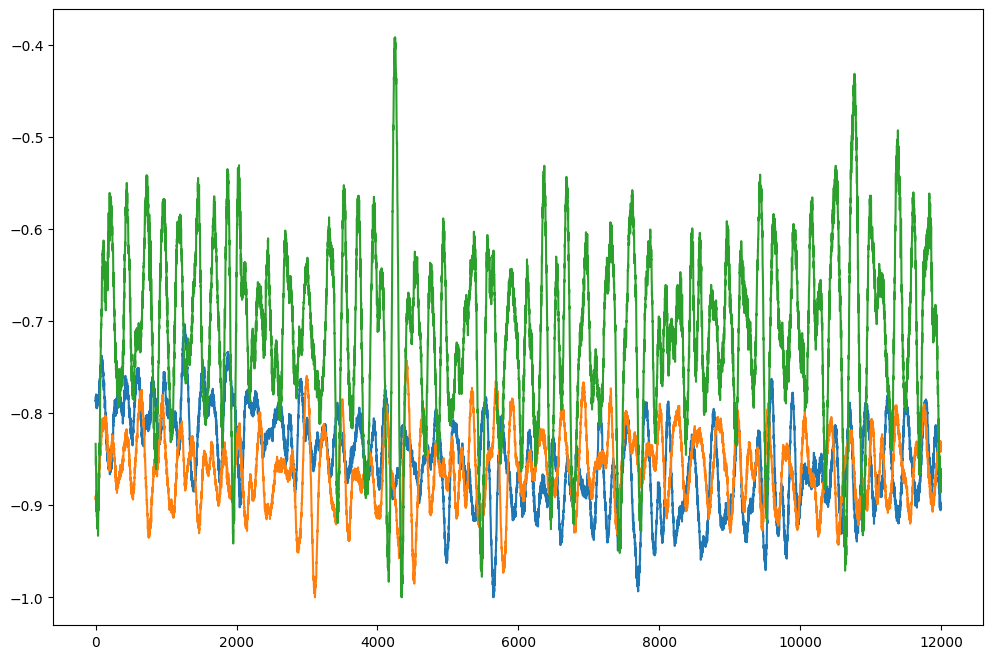

In [69]:
plt.plot(noise_data[109, :].T)

In [60]:
np.save("IRIS_non_earthquake_waveforms_1000_samples.npy", noise_data)

In [59]:
y_earthquake_data = np.ones((len(df),1))
y_noise_data = np.zeros((len(noise_data),1))
W = np.concatenate([earthquake_data,noise_data], axis=0)
Y = np.concatenate([y_earthquake_data, y_noise_data], axis=0)
W.shape,Y.shape

((1105, 3, 12000), (1105, 1))

In [61]:
np.max(earthquake_data), np.min(earthquake_data)

(1.0, -1.0)

In [62]:
np.max(noise_data), np.min(noise_data)

(1.0, -1.0)

In [63]:
seed = 42
np.random.seed(seed)
np.random.shuffle(W)
np.random.seed(seed)
np.random.shuffle(Y)

In [64]:
Y

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

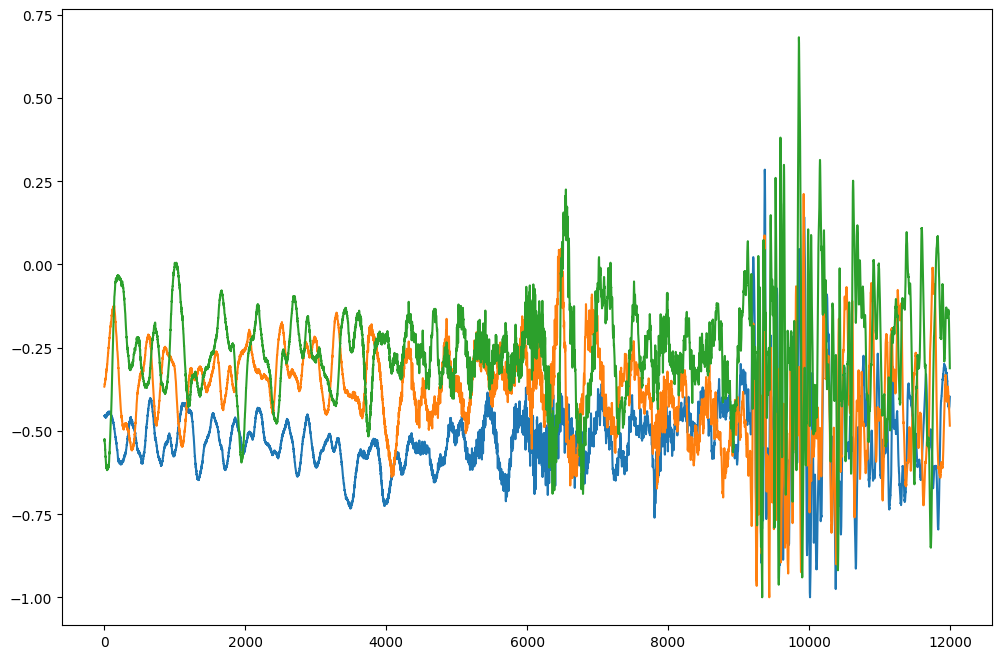

In [73]:
plt.plot(W[0].T)

In [67]:
np.save("IRIS_dataset_waveforms_train.npy", W)
np.save("IRIS_dataset_labels_train.npy",Y)

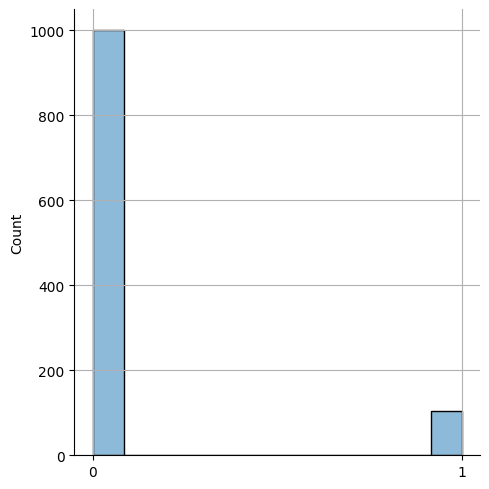

In [79]:
import seaborn as sns
sns.displot(Y,legend=False, kind='hist')
plt.xticks([0,1])
plt.grid()

In [5]:
import obspy
from obspy.clients.fdsn import Client

from obspy import UTCDateTime



client = Client("IRIS")

# Livermore
lon = -122.1753
lat = 46.2014

st = UTCDateTime("2022-09-03T20:52:15")

# Get currently active stations in 5 km radius around Livermore.
catalog = client.get_events(longitude=lon, latitude=lat, starttime=st - 100, endtime=st + 3600,
                        )
print(catalog)
catalog.plot(projection="local", resolution="i");

11 Event(s) in Catalog:
2022-09-03T21:49:41.205000Z | -32.733,  -72.380 | 4.2  Mwr
2022-09-03T21:42:26.560000Z | +38.485, -112.815 | 0.64 Ml
...
2022-09-03T20:56:19.950000Z | +37.570, -121.888 | 1.49 Md
2022-09-03T20:52:55.000000Z | +17.971,  -66.831 | 2.26 Md
To see all events call 'print(CatalogObject.__str__(print_all=True))'


ImportError: Cartopy could not be imported.

In [7]:
import pandas as pd

df2 = pd.DataFrame(columns=['time', 'latitude', 'longitude', 'depth', 'mag', 'magnitude_type', 'creation_info', 'info'])
    
    # Populate the DataFrame with event data
for i in range(len(catalog)):
        df2.loc[i, 'time'] = catalog[i].origins[0].time
        df2.loc[i, 'latitude'] = catalog[i].origins[0].latitude
        df2.loc[i, 'longitude'] = catalog[i].origins[0].longitude
        df2.loc[i, 'depth'] = catalog[i].origins[0].depth
        df2.loc[i, 'mag'] = catalog[i].magnitudes[0].mag
        df2.loc[i, 'magnitude_type'] = catalog[i].magnitudes[0].magnitude_type
        
        # Handle potential missing creation_info or event_descriptions
        creation_info = getattr(catalog[i].origins[0], 'creation_info', None)
        df2.loc[i, 'creation_info'] = creation_info if creation_info else 'N/A'
        
        event_description = catalog[i].event_descriptions[0].text if catalog[i].event_descriptions else 'N/A'
        df2.loc[i, 'info'] = event_description

In [8]:
df2

,time,latitude,longitude,depth,mag,magnitude_type,creation_info,info
0,2022-09-03T21:49:41.205000Z,-32.7328,-72.3796,13280.0,4.2,Mwr,"[agency_id, agency_uri, author, author_uri, cr...",OFF COAST OF CENTRAL CHILE
1,2022-09-03T21:42:26.560000Z,38.484833,-112.815167,5420.0,0.64,Ml,"[agency_id, agency_uri, author, author_uri, cr...",UTAH
2,2022-09-03T21:28:39.960000Z,38.820168,-122.844002,2210.0,0.64,Md,"[agency_id, agency_uri, author, author_uri, cr...",NORTHERN CALIFORNIA
3,2022-09-03T21:25:21.349000Z,38.1687,-117.7997,7200.0,1.5,ml,"[agency_id, agency_uri, author, author_uri, cr...",NEVADA
4,2022-09-03T21:23:43.810000Z,53.849167,-166.650833,8270.0,1.0,Ml,"[agency_id, agency_uri, author, author_uri, cr...","FOX ISLANDS, ALEUTIAN ISLANDS"
5,2022-09-03T21:19:26.147000Z,65.4535,-153.3734,10000.0,1.3,ml,"[agency_id, agency_uri, author, author_uri, cr...",NORTHERN ALASKA
6,2022-09-03T21:13:43.900000Z,49.367333,-120.523,-370.0,2.35,Ml,"[agency_id, agency_uri, author, author_uri, cr...","BRITISH COLUMBIA, CANADA"
7,2022-09-03T21:11:34.360000Z,46.868833,-121.752333,5760.0,0.42,Ml,"[agency_id, agency_uri, author, author_uri, cr...",WASHINGTON
8,2022-09-03T21:01:10.290000Z,37.615,-118.836333,3640.0,0.61,Md,"[agency_id, agency_uri, author, author_uri, cr...",CALIFORNIA-NEVADA BORDER REGION
9,2022-09-03T20:56:19.950000Z,37.569833,-121.887667,9310.0,1.49,Md,"[agency_id, agency_uri, author, author_uri, cr...",CENTRAL CALIFORNIA


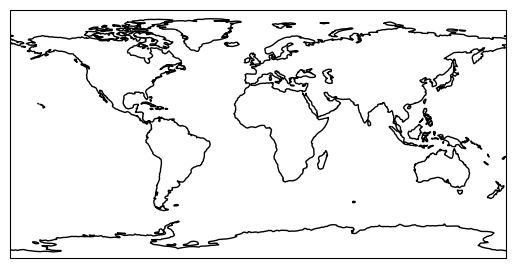

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Create a simple map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Display the map
plt.show()

In [20]:
inventory = client.get_stations(network="CC", station="FLAT",
                                level="channel")
print(inventory)

Inventory created at 2024-06-11T13:56:58.224100Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?network=CC&station=F...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			CC
		Stations (1):
			CC.FLAT (Flattop (PEPRO))
		Channels (3):
			CC.FLAT..BHZ, CC.FLAT..BHN, CC.FLAT..BHE


In [30]:
import cartopy as crt
import cartopy.feature as cfeature
event = catalog[0]
origin = event.origins[0]

# Livermore
lon = -122.1753
lat = 46.2014

st = UTCDateTime("2022-09-03T20:52:15")

# Get currently active stations in 5 km radius around Livermore.
inventory = client.get_stations(longitude=lon, latitude=lat,
                                maxradius=0.05, level="channel", 
                                starttime=st)
print(inventory)


Inventory created at 2024-06-11T14:15:07.098600Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2022-09-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (3):
			CC, SY, UW
		Stations (24):
			CC.EDOM (East Dome DOAS)
			CC.GUAC (Guacamole, crater of Mount St. Helens)
			CC.HOA (Hoala)
			CC.LOO (Loowit)
			CC.REM (Rembrant, Mount St. Helens)
			CC.SEP (September lobe, Mt. St. Helens (Dome sta))
			CC.STD (Studebaker Ridge, Mount St. Helens)
			CC.SUG (Sugar Bowl)
			CC.SWF2 (Southwest Flank 2, Mount St. Helens)
			CC.USFR (Upper South Fork Repeater)
			CC.VALT (Vault, Mount St. Helens)
			SY.HOA (HOA synthetic)
			SY.LOO (LOO synthetic)
			SY.REM (REM synthetic)
			SY.STD (STD synthetic)
			SY.SUG (SUG synthetic)
			SY.SWF2 (SWF2 synthetic)
			SY.SWFL (SWFL synthetic)
			SY.USFR (USFR synthetic)
			SY.VALT (VALT synthetic)
			UW.EDM (East Dome, Mt. St. Helens, WA, USA)
			UW.HSR (South Ri

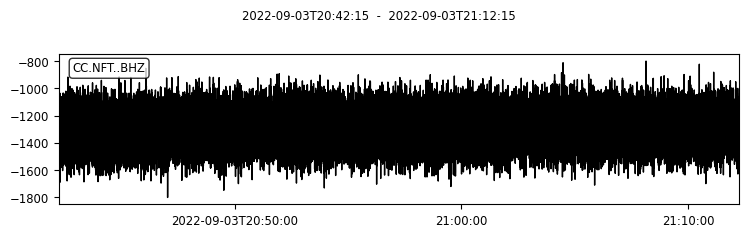

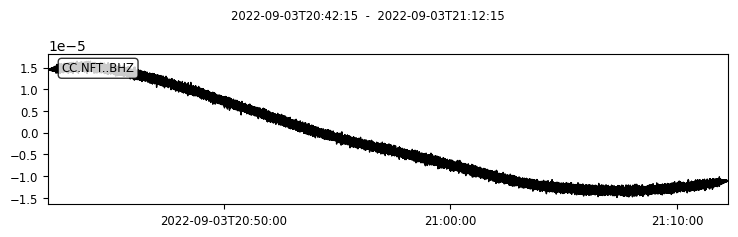

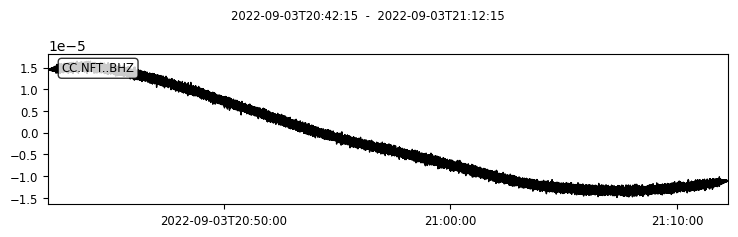

In [25]:
t = obspy.UTCDateTime("2022-09-03T20:52:15")  
st = client.get_waveforms("CC", "NFT", "--", "BHZ",
                          t - 10 * 60, t + 20 * 60)
inv = client.get_stations(network="CC", station="NFT", location="--", channel="BHZ",
                          level="response", starttime=t - 10, endtime=t + 10)
st.plot()

st.remove_response(inventory=inv)
st.plot()

In [33]:
station_data = []

for network in inventory:
    for station in network:
        for channel in station:
            station_data.append([network.code, station.code, channel.code])

# Convert the list to a DataFrame
df2 = pd.DataFrame(station_data, columns=["Network", "Station", "Channel"])

In [34]:
df2

,Network,Station,Channel
0,CC,EDOM,HDF
1,CC,EDOM,HDF
2,CC,EDOM,HDF
3,CC,EDOM,HDF
4,CC,EDOM,HDF
...,...,...,...
250,UW,SHW,VM1
251,UW,SHW,VM2
252,UW,SHW,VM3
253,UW,SHW,VPB


In [44]:
starttime = UTCDateTime("2022-09-03T20:52:15")-20
et = starttime + 100

for index, row in df2.iterrows():
    network = row["Network"]
    station = row["Station"]
    channel = row["Channel"]
    
    try:
        # Download waveform data
        st = client.get_waveforms(network=network, station=station, location="--", channel=channel, starttime=starttime, endtime=et)
        
        # Add the retrieved waveform to the stream
        waveforms += st
    except Exception as e:
        print(f"Failed to download data for {network}.{station}.{channel}: {e}")

# Save the combined waveform data in MiniSEED format
waveforms.write("event_waveforms.mseed", format="MSEED")



Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.EDOM.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.GUAC.CDF: No data available for request.
HTTP Status code: 204
Detailed response of server:


Failed to download data for CC.GUAC.HDF: No data available for request.
HTTP Status code: 204
Detailed response of server:




NameError: name 'waveforms' is not defined

In [ ]:
# Optionally, plot the waveforms
waveforms.plot()